# Model Training — Companion Notebook

> Companion for `src/my_mlops_project/pipelines/model_train/`.
> Shows the three Optuna-tuned, MLflow-logged candidate models and their
> validation comparison (the report's model table).

**Purpose:** train Logistic Regression, Random Forest, Gradient Boosting; tune
each with **Optuna** (maximising validation ROC-AUC); log every run to **MLflow**.

**Inputs:** `05_model_input/` splits. **Outputs:** `trained_models.pkl`,
`training_metrics.json`, + MLflow runs.

## Table of Contents
1. [Setup](#1-setup)
2. [Load the trained models + metrics](#2-load-the-trained-models--metrics)
3. [Model comparison](#3-model-comparison)
4. [Which model wins?](#4-which-model-wins)
5. [The MLflow runs](#5-the-mlflow-runs)
6. [Notes for the report](#6-notes-for-the-report)

## 1. Setup

In [1]:
import os, sys, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)                 # so sqlite:///mlflow.db resolves to the project store
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA = PROJECT_ROOT / "data"
print("working dir:", Path.cwd().name)

working dir: Project


## 2. Load the trained models + metrics

The heavy training happens in the pipeline (`kedro run --pipeline=model_train`);
this notebook loads its outputs so it runs in a second.

In [2]:
import pickle
metrics = json.load(open(DATA / "08_reporting" / "training_metrics.json"))
trained = pickle.load(open(DATA / "06_models" / "trained_models.pkl", "rb"))
print("families trained:", list(trained))

families trained: ['LogisticRegression', 'RandomForest', 'GradientBoosting']


## 3. Model comparison

Validation metrics per family. ROC-AUC is the primary metric (honest on the ~22% imbalance); PR-AUC and F1 are reported alongside.

In [3]:
comparison = (
    pd.DataFrame(metrics).T[["roc_auc", "pr_auc", "f1", "accuracy"]]
    .sort_values("roc_auc", ascending=False)
)
print((comparison.round(4)).to_string())

                    roc_auc  pr_auc      f1  accuracy
GradientBoosting     0.8010  0.5952  0.4802    0.8245
RandomForest         0.7989  0.5987  0.5557    0.7764
LogisticRegression   0.7783  0.5422  0.5464    0.7618


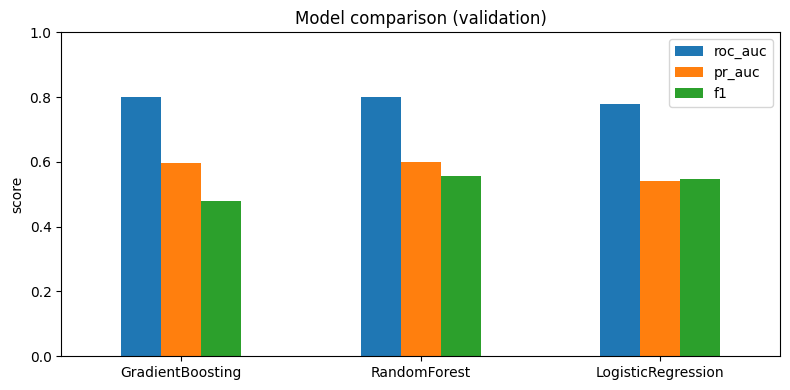

In [4]:
ax = comparison[["roc_auc", "pr_auc", "f1"]].plot(kind="bar", figsize=(8, 4))
ax.set_title("Model comparison (validation)")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(DATA / "08_reporting" / "model_comparison.png", dpi=120)
plt.show()

## 4. Which model wins?

In [5]:
best_family = comparison.index[0]
print(f"Best family by ROC-AUC: {best_family} "
      f"(roc_auc={comparison.loc[best_family, 'roc_auc']:.4f}, "
      f"pr_auc={comparison.loc[best_family, 'pr_auc']:.4f})")
print("\nThis is the champion candidate -> registered + explained in model_selection.")

Best family by ROC-AUC: GradientBoosting (roc_auc=0.8010, pr_auc=0.5952)

This is the champion candidate -> registered + explained in model_selection.


## 5. The MLflow runs

Every family was logged to MLflow with its best Optuna params, validation
metrics, and the model artifact. View them interactively with
`mlflow ui` (or `.\.venv-mlops\Scripts\python.exe -m mlflow ui`).

In [6]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
try:
    runs = mlflow.search_runs(experiment_names=["credit_default"])
    cols = ["tags.model_family"] + [c for c in runs.columns if c.startswith("metrics.")]
    print(runs[[c for c in cols if c in runs.columns]].head(10).to_string())
except Exception as e:
    print("MLflow query skipped:", type(e).__name__, "- view runs with `mlflow ui`")

    tags.model_family  metrics.accuracy  metrics.pr_auc  metrics.f1  metrics.roc_auc
0        RandomForest          0.776443        0.598677    0.555703         0.798889
1  LogisticRegression          0.761762        0.542215    0.546379         0.778307
2                None               NaN             NaN         NaN              NaN
3                None               NaN             NaN         NaN              NaN
4                None               NaN             NaN         NaN              NaN
5                None               NaN             NaN         NaN              NaN
6                None               NaN             NaN         NaN              NaN
7                None               NaN             NaN         NaN              NaN
8                None               NaN             NaN         NaN              NaN
9                None               NaN             NaN         NaN              NaN


## 6. Notes for the report

> For [`../report/REPORT_OUTLINE.md`](../report/REPORT_OUTLINE.md) §3 (results / modelling).

- **Three families compared** — Logistic Regression (scaled), Random Forest,
  Gradient Boosting — each **Optuna-tuned** (TPE sampler) to maximise validation
  ROC-AUC, the metric that doesn't lie on a 22%-positive target.
- **MLflow tracks everything** — one run per family with best hyperparameters,
  metrics, and the signed model; directly comparable in the UI.
- **The comparison table (§3) + bar chart (`model_comparison.png`)** go straight
  into the report; the winner becomes the champion in `model_selection`.